# Analisi e Visualizzazione del Training di un Singolo Livello

Questo notebook analizza i log di training di un singolo livello, visualizzando l'andamento del reward nel tempo.

### Importazione delle Librerie

Importiamo le librerie necessarie:
- `pandas`: per la manipolazione dei dati
- `matplotlib`: per la visualizzazione
- `numpy`: per calcoli numerici

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as m_lines
import numpy as np
import json
import yaml
import os

### Funzione per Caricare i Dati

Questa funzione legge il file CSV con i log del training.
Il file ha una prima riga con metadati in formato JSON e poi i dati con colonne:
- `r`: reward
- `l`: lunghezza episodio
- `t`: tempo

In [32]:
def load_level_data(file_path):
    """
    Carica i dati dal file CSV del livello.

    Args:
        file_path: Path al file CSV

    Returns:
        df: DataFrame con i dati
        metadata: Dizionario con i metadati
    """
    # Leggi la prima riga per i metadati
    with open(file_path, 'r') as f:
        first_line = f.readline().strip()
        # Rimuovi il prefisso '#' e parsa il JSON
        metadata_str = first_line.lstrip('#')
        try:
            metadata = json.loads(metadata_str)
        except:
            metadata = {}

    # Leggi i dati saltando la prima riga (metadati)
    df = pd.read_csv(file_path, skiprows=1)

    return df, metadata

### Funzione per Leggere il Mean Reward dal Curriculum

Questa funzione legge il file YAML del curriculum e estrae il valore `mean_reward` target per il livello specificato.

In [33]:
def load_mean_reward_from_curriculum(curriculum_path, level_name):
    """
    Carica il mean_reward target dal file curriculum YAML.

    Args:
        curriculum_path: Path al file curriculum YAML
        level_name: Nome del livello

    Returns:
        mean_reward: Valore target del mean_reward, None se non trovato
    """
    try:
        with open(curriculum_path, 'r') as f:
            curriculum = yaml.safe_load(f)

        if 'Curriculum' in curriculum and level_name in curriculum['Curriculum']:
            mean_reward = curriculum['Curriculum'][level_name].get('mean_reward')
            return mean_reward
        else:
            print(f"Livello '{level_name}' non trovato nel curriculum")
            return None
    except FileNotFoundError:
        print(f"File curriculum non trovato: {curriculum_path}")
        return None
    except Exception as e:
        print(f"Errore nella lettura del curriculum: {e}")
        return None

### Funzione per Plottare i Reward

Questa funzione crea un grafico dell'andamento dei reward durante il training.
Include sia i dati grezzi che una versione smoothed per vedere meglio il trend.

In [34]:
def plot_reward(df, level_name='Level', window_size=10, save_path=None, mean_reward_target=None):
    """
    Plotta l'andamento del reward durante il training.

    Args:
        df: DataFrame con colonne 'r' (reward), 'l' (length), 't' (time)
        level_name: Nome del livello per il titolo
        window_size: Dimensione della finestra per lo smoothing
        save_path: Path dove salvare il grafico (opzionale)
        mean_reward_target: Target mean_reward dal curriculum (opzionale)
    """
    # Calcola il reward smoothed usando una media mobile
    df_smooth = df['r'].rolling(window=window_size).mean()

    # Crea il grafico
    fig, ax = plt.subplots(figsize=(22, 9))

    # Plotta i reward grezzi e smoothed
    ax.plot(df['t'], df['r'], color='#3399e6', lw=2, alpha=0.5, label='Reward')
    ax.plot(df['t'], df_smooth, color='red', lw=2, label='Reward Smoothed')

    # Aggiungi una linea orizzontale per il reward medio
    mean_reward = df['r'].mean()
    ax.axhline(y=mean_reward, color='green', linestyle='--', lw=1.5, label=f'Media Effettiva: {mean_reward:.2f}')

    # Aggiungi la linea del target dal curriculum se disponibile
    legend_handles = []
    if mean_reward_target is not None:
        ax.axhline(y=mean_reward_target, color='orange', linestyle=':', lw=2.5, label=f'Target Curriculum: {mean_reward_target:.2f}')
        # Evidenzia la zona target
        ax.axhspan(mean_reward_target - 0.5, mean_reward_target + 0.5, alpha=0.1, color='orange')

    # Configura il grafico
    plt.xlabel('Tempo (secondi)', fontsize=20)
    plt.ylabel('Reward', fontsize=20)
    plt.title(f'Andamento Reward durante Training - {level_name}', fontsize=24)

    # Crea la legenda personalizzata
    blue_line = m_lines.Line2D([], [], color='#3399e6', markersize=15, label='Reward', linewidth=2)
    red_line = m_lines.Line2D([], [], color='red', markersize=15, label='Reward Smoothed', linewidth=2)
    green_line = m_lines.Line2D([], [], color='green', markersize=15, label=f'Media Effettiva: {mean_reward:.2f}', linewidth=2, linestyle='--')

    legend_handles = [blue_line, red_line, green_line]

    if mean_reward_target is not None:
        orange_line = m_lines.Line2D([], [], color='orange', markersize=15, label=f'Target Curriculum: {mean_reward_target:.2f}', linewidth=2.5, linestyle=':')
        legend_handles.append(orange_line)

    plt.legend(handles=legend_handles, loc='upper right', fontsize=20)
    plt.grid(True, alpha=0.3)

    # Salva se specificato
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()

    # Stampa statistiche
    print(f"\n=== Statistiche Reward - {level_name} ===")
    print(f"Reward medio effettivo: {df['r'].mean():.3f}")
    if mean_reward_target is not None:
        print(f"Reward target curriculum: {mean_reward_target:.3f}")
        diff = df['r'].mean() - mean_reward_target
        print(f"Differenza (effettivo - target): {diff:.3f}")
    print(f"Reward minimo: {df['r'].min():.3f}")
    print(f"Reward massimo: {df['r'].max():.3f}")
    print(f"Deviazione standard: {df['r'].std():.3f}")
    print(f"Numero di episodi: {len(df)}")

### Funzione per Plottare la Lunghezza degli Episodi

Questa funzione crea un grafico dell'andamento della lunghezza degli episodi.

In [35]:
def plot_episode_length(df, level_name='Level', window_size=10, save_path=None):
    """
    Plotta l'andamento della lunghezza degli episodi durante il training.

    Args:
        df: DataFrame con colonne 'r' (reward), 'l' (length), 't' (time)
        level_name: Nome del livello per il titolo
        window_size: Dimensione della finestra per lo smoothing
        save_path: Path dove salvare il grafico (opzionale)
    """
    # Calcola la lunghezza smoothed
    df_smooth = df['l'].rolling(window=window_size).mean()

    # Crea il grafico
    fig, ax = plt.subplots(figsize=(22, 9))

    # Plotta i dati
    ax.plot(df['t'], df['l'], color='#3399e6', lw=2, alpha=0.5, label='Lunghezza Episodio')
    ax.plot(df['t'], df_smooth, color='red', lw=2, label='Lunghezza Smoothed')

    # Media
    mean_length = df['l'].mean()
    ax.axhline(y=mean_length, color='green', linestyle='--', lw=1.5, label=f'Media: {mean_length:.1f}')

    # Configura il grafico
    plt.xlabel('Tempo (secondi)', fontsize=20)
    plt.ylabel('Lunghezza Episodio', fontsize=20)
    plt.title(f'Andamento Lunghezza Episodi - {level_name}', fontsize=24)

    # Legenda
    blue_line = m_lines.Line2D([], [], color='#3399e6', markersize=15, label='Lunghezza Episodio', linewidth=2)
    red_line = m_lines.Line2D([], [], color='red', markersize=15, label='Lunghezza Smoothed', linewidth=2)
    green_line = m_lines.Line2D([], [], color='green', markersize=15, label=f'Media: {mean_length:.1f}', linewidth=2, linestyle='--')

    plt.legend(handles=[blue_line, red_line, green_line], loc='upper right', fontsize=20)
    plt.grid(True, alpha=0.3)

    # Salva se specificato
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()

    # Stampa statistiche
    print(f"\n=== Statistiche Lunghezza Episodi - {level_name} ===")
    print(f"Lunghezza media: {df['l'].mean():.1f}")
    print(f"Lunghezza minima: {df['l'].min():.0f}")
    print(f"Lunghezza massima: {df['l'].max():.0f}")

### Configurazione e Caricamento Dati

Specifica qui il percorso del file CSV e il nome del livello.

In [36]:
level_name = "CorridorObjt"  # Modifica con il nome del livello
file_path = "../output/logs/" + level_name + "_logs/" + level_name + ".monitor.csv"  # Modifica con il tuo path
output_folder = "../output/plots/"  # Cartella dove salvare i grafici
curriculum_path = "../scripts/configs/curriculumObjective/curriculum_lab2.yaml"  # Path al curriculum

# Carica i dati
df, metadata = load_level_data(file_path)

# Carica il mean_reward target dal curriculum
mean_reward_target = load_mean_reward_from_curriculum(curriculum_path, level_name)

print(f"Dati caricati: {len(df)} episodi")
print(f"Metadati: {metadata}")
if mean_reward_target is not None:
    print(f"Target mean_reward dal curriculum: {mean_reward_target}")
print(f"\nPrime righe del dataset:")
df.head(10)

Dati caricati: 150 episodi
Metadati: {'t_start': 1759912844.6275668, 'env_id': 'None'}
Target mean_reward dal curriculum: 8.7

Prime righe del dataset:


,r,l,t
0,8.916599,32,1.780646
1,8.916499,33,1.850854
2,8.856400,34,1.903785
3,8.796200,36,2.007976
4,8.796200,36,2.007976
5,9.095699,41,2.270215
6,8.615600,42,2.322413
7,8.975499,43,2.375298
8,8.615399,44,2.430095
9,8.915199,46,2.534255


### Visualizzazione Reward

Crea il grafico dell'andamento dei reward.

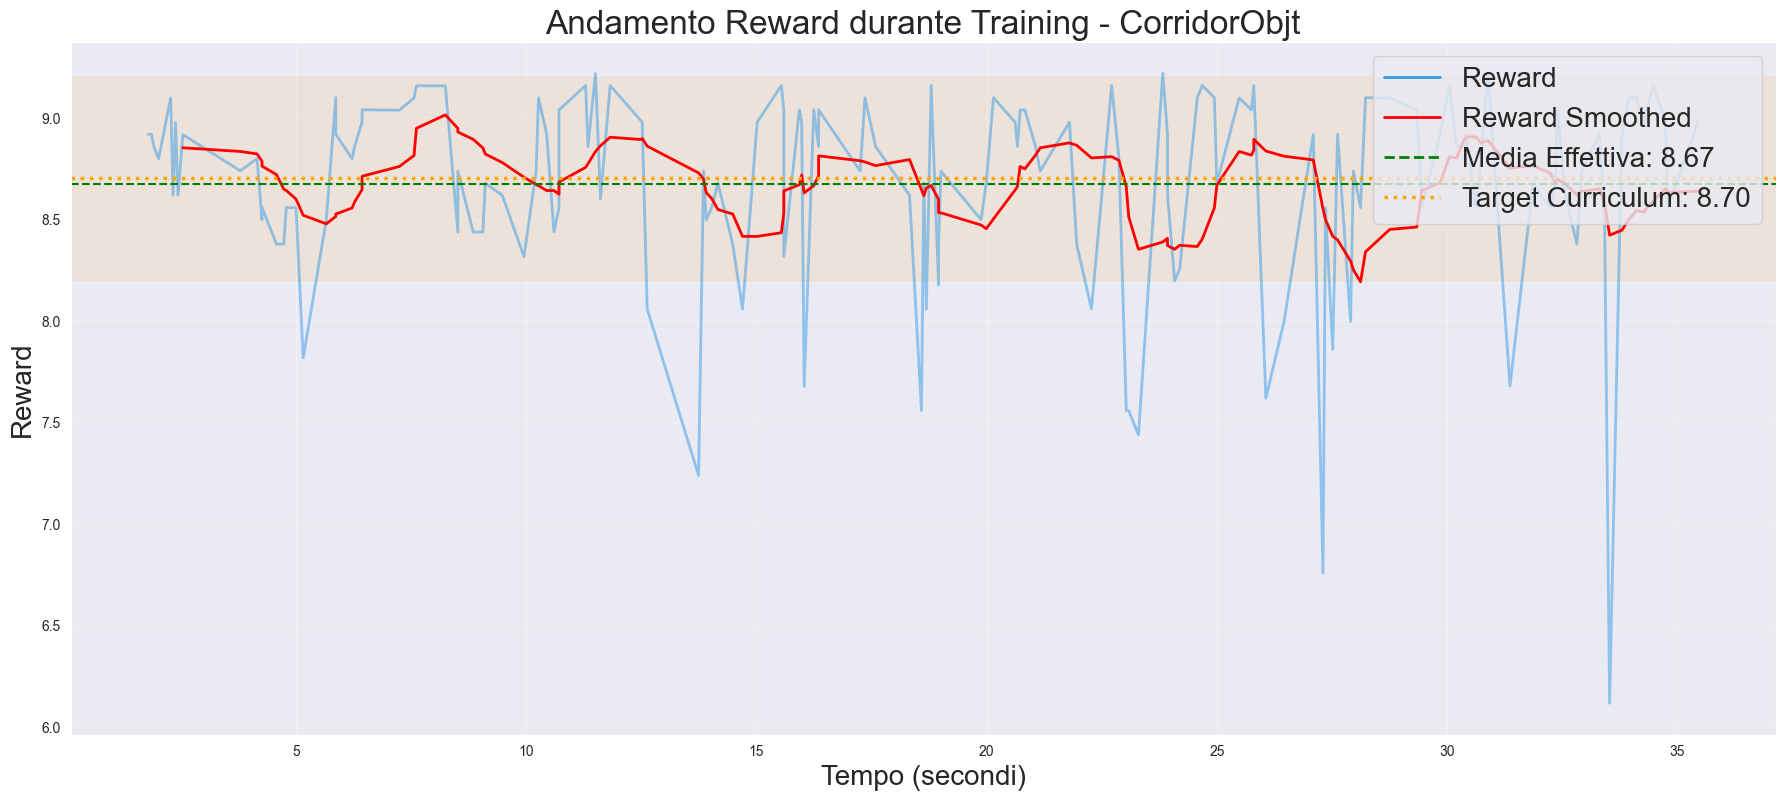


=== Statistiche Reward - CorridorObjt ===
Reward medio effettivo: 8.673
Reward target curriculum: 8.700
Differenza (effettivo - target): -0.027
Reward minimo: 6.113
Reward massimo: 9.217
Deviazione standard: 0.494
Numero di episodi: 150


In [37]:
plot_reward(
    df,
    level_name=level_name,
    window_size=10,  # Modifica per cambiare lo smoothing
    save_path=f"{output_folder}reward_{level_name}.png",
    mean_reward_target=mean_reward_target
)

### Visualizzazione Lunghezza Episodi

Crea il grafico dell'andamento della lunghezza degli episodi.


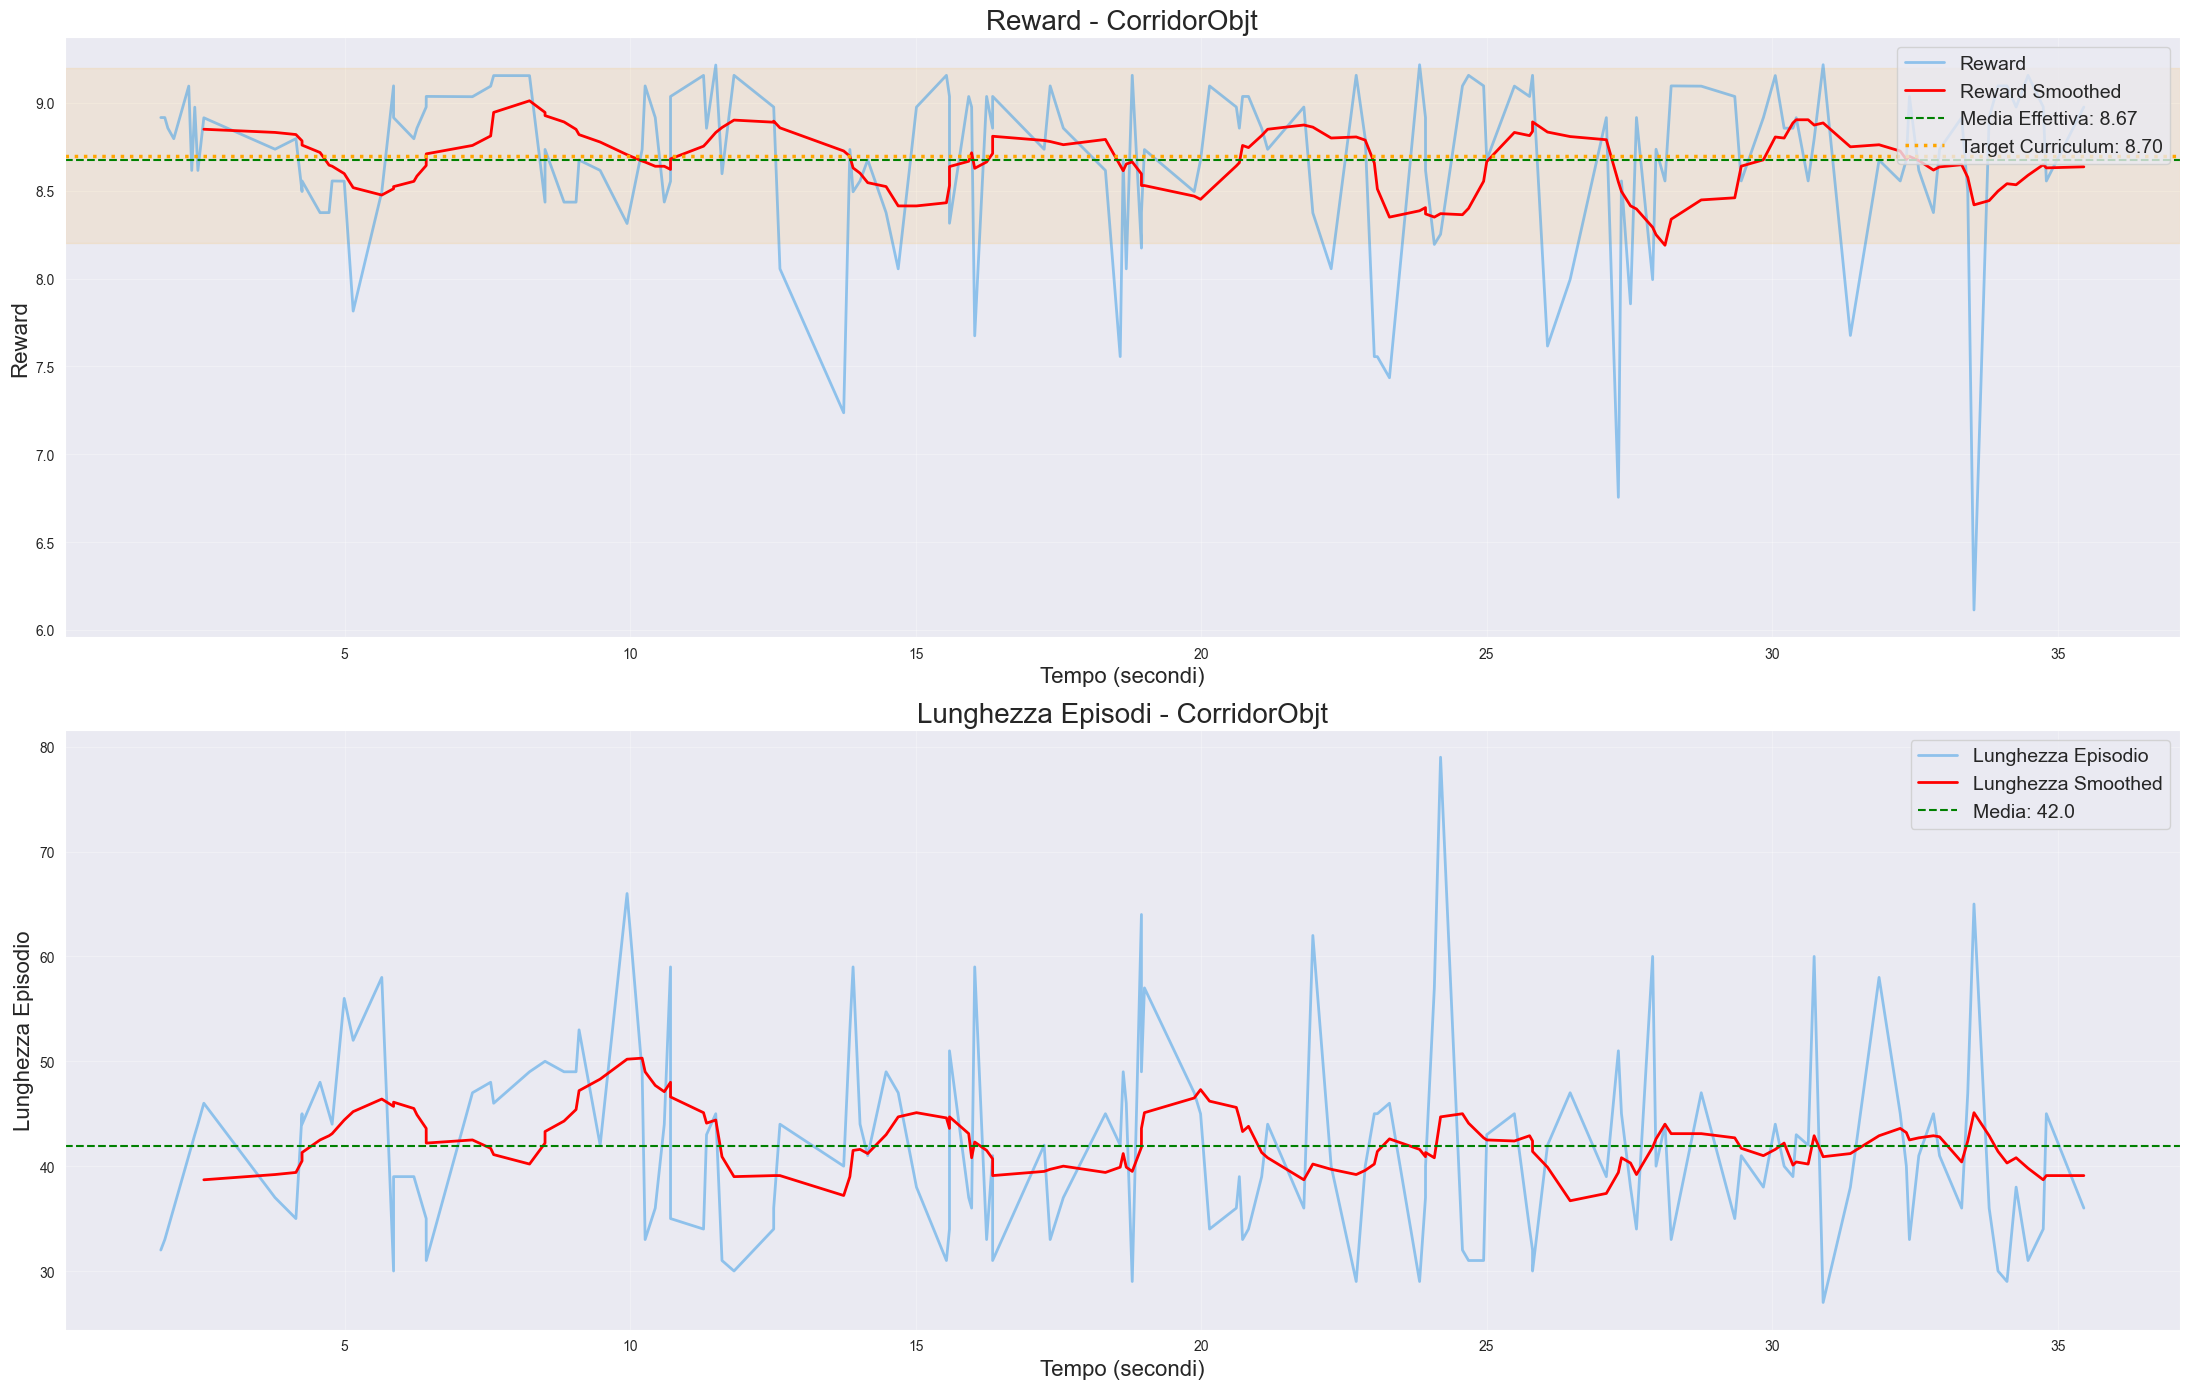

In [38]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 14))

# Smoothing
window_size = 10
reward_smooth = df['r'].rolling(window=window_size).mean()
length_smooth = df['l'].rolling(window=window_size).mean()

# Grafico reward
ax1.plot(df['t'], df['r'], color='#3399e6', lw=2, alpha=0.5, label='Reward')
ax1.plot(df['t'], reward_smooth, color='red', lw=2, label='Reward Smoothed')
ax1.axhline(y=df['r'].mean(), color='green', linestyle='--', lw=1.5, label=f"Media Effettiva: {df['r'].mean():.2f}")

# Aggiungi target dal curriculum
if mean_reward_target is not None:
    ax1.axhline(y=mean_reward_target, color='orange', linestyle=':', lw=2.5, label=f'Target Curriculum: {mean_reward_target:.2f}')
    ax1.axhspan(mean_reward_target - 0.5, mean_reward_target + 0.5, alpha=0.1, color='orange')

ax1.set_xlabel('Tempo (secondi)', fontsize=16)
ax1.set_ylabel('Reward', fontsize=16)
ax1.set_title(f'Reward - {level_name}', fontsize=20)
ax1.legend(loc='upper right', fontsize=14)
ax1.grid(True, alpha=0.3)

# Grafico lunghezza episodi
ax2.plot(df['t'], df['l'], color='#3399e6', lw=2, alpha=0.5, label='Lunghezza Episodio')
ax2.plot(df['t'], length_smooth, color='red', lw=2, label='Lunghezza Smoothed')
ax2.axhline(y=df['l'].mean(), color='green', linestyle='--', lw=1.5, label=f"Media: {df['l'].mean():.1f}")
ax2.set_xlabel('Tempo (secondi)', fontsize=16)
ax2.set_ylabel('Lunghezza Episodio', fontsize=16)
ax2.set_title(f'Lunghezza Episodi - {level_name}', fontsize=20)
ax2.legend(loc='upper right', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs(output_folder, exist_ok=True)
plt.savefig(f"{output_folder}combined_{level_name}.png", bbox_inches='tight')
plt.show()